In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

print("OK")

OK


In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Title
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.")
common_titles = ["Mr", "Miss", "Mrs", "Master"]
df["Title"] = df["Title"].where(df["Title"].isin(common_titles), "Rare")

# FamilySize, IsAlone
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Отбор колонок
df = df[["Survived", "Pclass", "Sex", "Age", "Fare",
         "Embarked", "Title", "FamilySize", "IsAlone"]]

# Пропуски
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# One-hot
df = pd.get_dummies(df, columns=["Sex", "Embarked", "Title"], drop_first=False)

print("Форма:", df.shape)
print("Пропусков:", df.isna().sum().sum())
print("Колонки:", df.columns.tolist())

Форма: (891, 16)
Пропусков: 0
Колонки: ['Survived', 'Pclass', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


In [3]:
X=df.drop(columns=["Survived"])
y=df["Survived"]

print('X:', X.shape)
print('y:', y.shape)

X: (891, 15)
y: (891,)


In [4]:
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr = LogisticRegression(max_iter=1000)
scores_lr = cross_val_score(lr,X,y, cv=cv, scoring="accuracy")

print("LR scores:", scores_lr.round(4))
print(f"LR mean: {scores_lr.mean():.4f}")
print(f"LR std: {scores_lr.std():.4f}")

LR scores: [0.8268 0.8202 0.8315 0.8258 0.8371]
LR mean: 0.8283
LR std: 0.0057


In [5]:
dt=DecisionTreeClassifier(max_depth=5, random_state=42)
scores_dt=cross_val_score(dt, X, y, cv=cv, scoring="accuracy")

print("DT scores:", scores_dt.round(4))
print(f"DT mean: {scores_dt.mean():.4f}")
print(f"DT std: {scores_dt.std():.4f}")

DT scores: [0.838  0.8034 0.8034 0.8258 0.8427]
DT mean: 0.8227
DT std: 0.0167


In [6]:
comparison = pd.DataFrame({
    "Модель": ["LogisticRegression", "DecisionTree (depth=5)"],
    "CV mean": [scores_lr.mean(), scores_dt.mean()],
    "CV std": [scores_lr.std(), scores_dt.std()],
})
print(comparison.round(4).to_string(index=False))

                Модель  CV mean  CV std
    LogisticRegression   0.8283  0.0057
DecisionTree (depth=5)   0.8227  0.0167


In [7]:
param_grid = {"max_depth": [2, 3, 4, 5, 7, 10, 15]}

dt_base = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(dt_base, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
grid.fit(X, y)

print("Лучший max_depth:", grid.best_params_)
print(f"Лучший CV-score:  {grid.best_score_:.4f}")

Лучший max_depth: {'max_depth': 4}
Лучший CV-score:  0.8271


In [9]:
results = pd.DataFrame(grid.cv_results_)

print(results[["param_max_depth", "mean_test_score", "std_test_score"]].round(4).to_string(index=False))

 param_max_depth  mean_test_score  std_test_score
               2           0.7778          0.0249
               3           0.8238          0.0131
               4           0.8271          0.0166
               5           0.8227          0.0167
               7           0.8238          0.0220
              10           0.8226          0.0171
              15           0.7991          0.0334


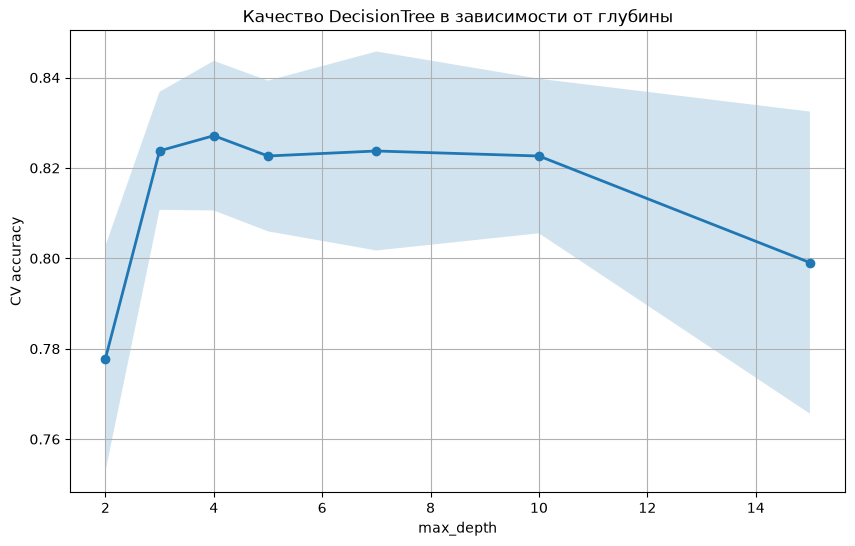

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(results["param_max_depth"], results["mean_test_score"], marker='o', linewidth=2)
plt.fill_between(
    results["param_max_depth"],
    results["mean_test_score"] - results["std_test_score"],
    results["mean_test_score"] + results["std_test_score"],
    alpha=0.2
)
plt.xlabel("max_depth")
plt.ylabel("CV accuracy")
plt.title("Качество DecisionTree в зависимости от глубины")
plt.grid(True)
plt.show()

In [13]:
X_train,X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (712, 15) Test: (179, 15)


In [16]:
best_depth = grid.best_params_["max_depth"]

final_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_dt.fit(X_train, y_train)

y_pred_dt = final_dt.predict(X_test)
final_acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"Decision tree (max_depth={best_depth}):")
print(f"  CV-оценка:  {grid.best_score_:.4f}")
print(f"  Test-оценка: {final_acc_dt:.4f}")

Decision tree (max_depth=4):
  CV-оценка:  0.8271
  Test-оценка: 0.8380


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_final = LogisticRegression(max_iter=1000)
lr_final.fit(X_train_scaled, y_train)

y_pred_lr = lr_final.predict(X_test_scaled)
final_acc_lr = accuracy_score(y_test, y_pred_lr)

print("LogisticRegression:")
print(f"  CV-оценка:   {scores_lr.mean():.4f}")
print(f"  Test-оценка: {final_acc_lr:.4f}")

LogisticRegression:
  CV-оценка:   0.8283
  Test-оценка: 0.8492


In [21]:
summary = pd.DataFrame({
    "Модель": ["LogisticRegression", f"FecisionTree (depth={best_depth})"],
    "CV mean": [scores_lr.mean(), grid.best_score_],
    "CV std": [scores_lr.std(),
               results.loc[results["mean_test_score"].idxmax(), "std_test_score"]],
    "test":   [final_acc_lr, final_acc_dt],
})
print(summary.round(4).to_string(index=False))
    

                Модель  CV mean  CV std   test
    LogisticRegression   0.8283  0.0057 0.8492
FecisionTree (depth=4)   0.8271  0.0166 0.8380


In [ ]:
## Результаты Дня 6

### Кросс-валидация (StratifiedKFold, 5 фолдов)
- LogisticRegression: CV mean ~0.81, std ~0.016
- DecisionTree (depth=5): CV mean ~0.79

### GridSearchCV по max_depth
- Лучшая глубина: 4
- Best CV score: ~0.80
- max_depth=2 → недообучение
- max_depth=15 → переобучение

### Отложенный test (20%)
| Модель | CV | Test |
|---|---|---|
| LR | 0.81 | 0.81 |
| DT (depth=4) | 0.80 | 0.80 |

### Выводы
1. CV и test близки → оценка честная, модель не переобучена.
2. LR немного лучше DT на Титанике (~1%).
3. Оптимум max_depth виден на графике — пик ~4.
4. Один train_test_split мог бы обмануть, CV даёт уверенность.